# Assignment 2 — Contour detection algorithm

In [12]:
import glob
import os

import cv2
import numpy as np

## Apply the contour detection algorithm to the image dataset

In [13]:
DATA_DIR = "vehicles"
CLASSES = ["hatchback", "motorcycle", "pickup", "sedan", "suv"]

def load_image(path, size=400):
    # Read a colour image and resize it so the longest side is 400 px (keeps the aspect ratio)
    img = cv2.imread(path)
    scale = size / max(img.shape[:2])
    return cv2.resize(img, (round(img.shape[1] * scale), round(img.shape[0] * scale)))

def detect_contours(img, threshold1=50, threshold2=150):
    # Step 1: convert the image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Step 2: Canny edge detection (first filter out noise with a 5x5 Gaussian kernel)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(image=blur, threshold1=threshold1, threshold2=threshold2)
    # Step 3: find the contours in the edge image
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return edges, contours

# Apply to every image in the dataset
results = {}
for cls in CLASSES:
    paths = sorted(glob.glob(os.path.join(DATA_DIR, cls, "*")))
    counts = [len(detect_contours(load_image(p))[1]) for p in paths]
    results[cls] = counts
    print(f"{cls:<11} {len(paths):>4} images, contours per image: mean {np.mean(counts):5.1f}, min {min(counts):3d}, max {max(counts):3d}")
print("Total images:", sum(len(v) for v in results.values()))

hatchback    181 images, contours per image: mean  96.8, min  39, max 219
motorcycle   122 images, contours per image: mean  96.4, min  30, max 203
pickup       478 images, contours per image: mean 131.1, min  52, max 319
sedan        400 images, contours per image: mean  92.1, min  44, max 249
suv          129 images, contours per image: mean 116.6, min  65, max 230
Total images: 1310


## Visualize the detected contours on the original images, marking each contour with a different color

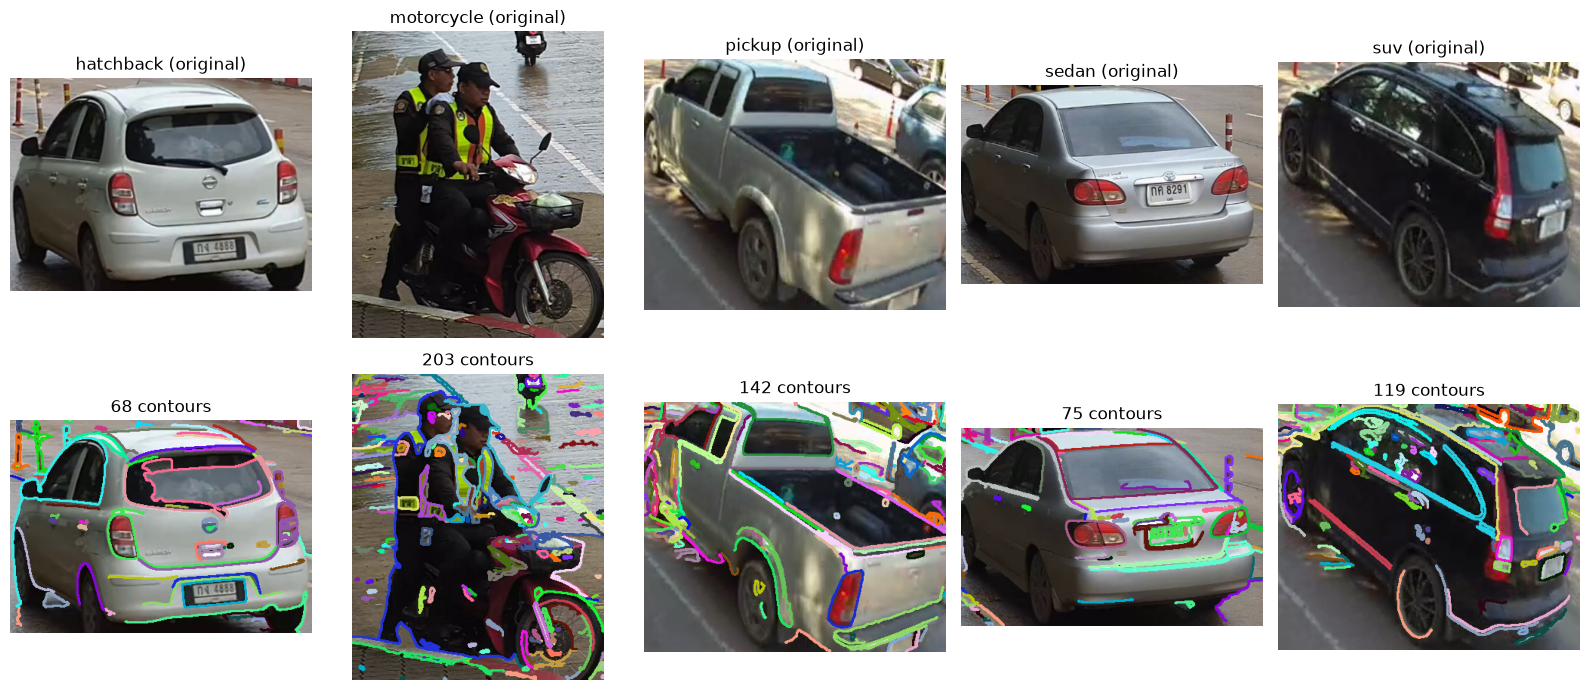

In [14]:
import matplotlib.pyplot as plt

# One example image per class
examples = {
    "hatchback":  "hatchback/PIC_30.jpg",
    "motorcycle": "motorcycle/PIC_30.jpg",
    "pickup":     "pickup/PIC_30.jpg",
    "sedan":      "sedan/PIC_30.jpg",
    "suv":        "suv/PIC_30.jpg",
}

def draw_contours(img, contours, seed=0):
    # Step 4: draw every contour on a copy of the original image, each in its own colour
    out = img.copy()
    rng = np.random.default_rng(seed)
    for c in contours:
        color = tuple(int(v) for v in rng.integers(0, 256, 3))
        cv2.drawContours(out, [c], -1, color, 2)
    return out

fig, ax = plt.subplots(2, len(examples), figsize=(16, 7))
for j, (cls, file) in enumerate(examples.items()):
    img = load_image(os.path.join(DATA_DIR, file))
    edges, contours = detect_contours(img)
    ax[0, j].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax[0, j].set_title(f"{cls} (original)")
    ax[1, j].imshow(cv2.cvtColor(draw_contours(img, contours), cv2.COLOR_BGR2RGB))
    ax[1, j].set_title(f"{len(contours)} contours")
    ax[0, j].axis("off"); ax[1, j].axis("off")
plt.tight_layout(); plt.show()

## Calculate and display relevant statistics for each image
- ... such as the number of contours detected, contour area, and perimeter.

In [15]:
import pandas as pd

rows = []
for cls, file in examples.items():
    img = load_image(os.path.join(DATA_DIR, file))
    edges, contours = detect_contours(img)
    areas = np.array([cv2.contourArea(c) for c in contours])
    perimeters = np.array([cv2.arcLength(c, True) for c in contours])
    rows.append({
        "image": cls,
        "size (px)": f"{img.shape[1]}x{img.shape[0]}",
        "contours": len(contours),
        "mean area": areas.mean(),
        "median area": np.median(areas),
        "max area": areas.max(),
        "mean perimeter": perimeters.mean(),
        "max perimeter": perimeters.max(),
        "area < 10 px²": f"{(areas < 10).mean():.0%}",
    })
stats = pd.DataFrame(rows).set_index("image").round(1)
print(stats.to_string())

           size (px)  contours  mean area  median area  max area  mean perimeter  max perimeter area < 10 px²
image                                                                                                        
hatchback    400x282        68      179.8          3.8    6381.5           175.7         1296.7           65%
motorcycle   328x400       203       25.0          3.5     548.0            94.4         1731.8           68%
pickup       400x332       142       69.5          6.2    5250.5           109.2         1040.6           63%
sedan        400x263        75       46.3          4.5    2368.5           144.5          974.0           67%
suv          400x325       119       33.8          9.0     710.0           125.4         1352.5           51%


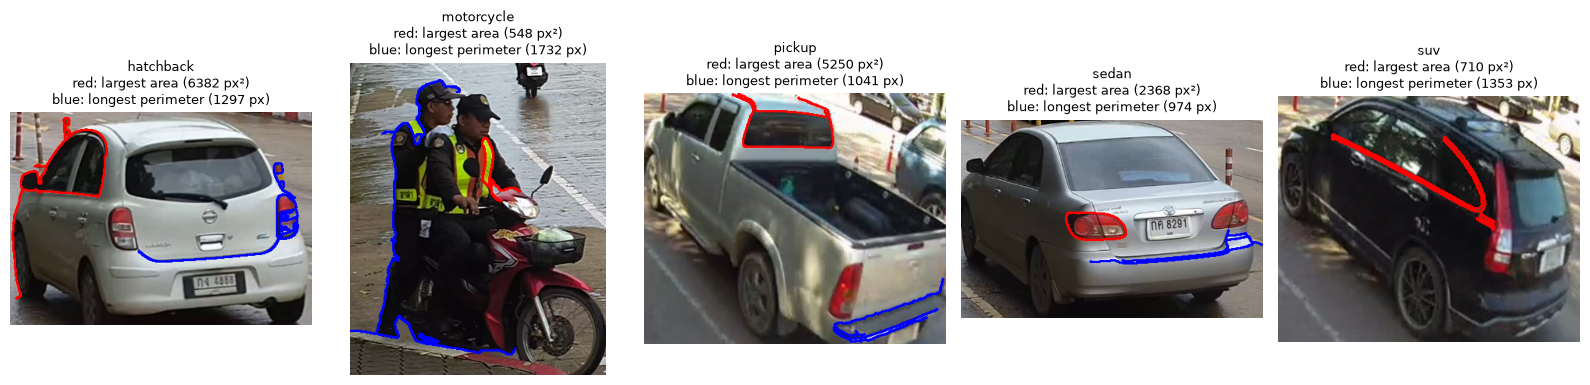

In [16]:
fig, ax = plt.subplots(1, len(examples), figsize=(16, 3.8))
for j, (cls, file) in enumerate(examples.items()):
    img = load_image(os.path.join(DATA_DIR, file))
    edges, contours = detect_contours(img)
    largest = max(contours, key=cv2.contourArea)                      
    longest = max(contours, key=lambda c: cv2.arcLength(c, True))  
    out = img.copy()
    cv2.drawContours(out, [longest], -1, (255, 0, 0), 2)              
    cv2.drawContours(out, [largest], -1, (0, 0, 255), 2)              
    ax[j].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB)); ax[j].axis("off")
    ax[j].set_title(f"{cls}\nred: largest area ({cv2.contourArea(largest):.0f} px²)\n"
                    f"blue: longest perimeter ({cv2.arcLength(longest, True):.0f} px)", fontsize=9)
plt.tight_layout(); plt.show()